<!-- type: tutorial -->
# Lag-Aware ModMRMR Showcase

This walkthrough builds a forecast-safe synthetic panel and compares the three shipped selection views for sparse covariate-lag triage.

It stays on the triage side of the hand-off boundary: no downstream model fitting is performed here.

## Setup

The setup cell below resolves the examples repo root even when the notebook is executed via `nbconvert`, switches plotting to the batch-safe `Agg` backend, and pre-creates the notebook output tree under `outputs/notebooks/walkthroughs/09_lag_aware_mod_mrmr_showcase/`.

> Prerequisite: these lag-aware notebooks require the local core checkout until v0.4.3 is published.

```bash
export FORECASTABILITY_LOCAL_DEV=1
bash ../ami/scripts/bootstrap_local_workspace.sh
```

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

try:
    from forecastability import LagAwareModMRMRConfig, PairwiseScorerSpec, run_lag_aware_mod_mrmr
except ImportError as exc:
    raise ImportError(
        "Lag-aware public imports are unavailable in the installed forecastability package. "
        "These notebooks require the local core checkout until v0.4.3 is published.\n\n"
        "Run:\n"
        "export FORECASTABILITY_LOCAL_DEV=1\n"
        "bash ../ami/scripts/bootstrap_local_workspace.sh"
    ) from exc

CWD = Path.cwd().resolve()
if (CWD / 'pyproject.toml').exists() and (CWD / 'walkthroughs').exists():
    REPO_ROOT = CWD
elif CWD.name == 'walkthroughs' and (CWD.parent / 'pyproject.toml').exists():
    REPO_ROOT = CWD.parent
else:
    raise RuntimeError(
        'Run this notebook from the forecastability-examples repo root or its walkthroughs directory.'
    )

os.chdir(REPO_ROOT)

NOTEBOOK_STEM = '09_lag_aware_mod_mrmr_showcase'
OUTPUT_ROOT = REPO_ROOT / 'outputs' / 'notebooks' / 'walkthroughs' / NOTEBOOK_STEM
FIG_DIR = OUTPUT_ROOT / 'figures'
TABLE_DIR = OUTPUT_ROOT / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42

pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 180)
pd.set_option('display.max_colwidth', 160)
pd.set_option('display.precision', 4)


def _relative_output_path(path: Path) -> str:
    try:
        return str(path.relative_to(REPO_ROOT))
    except ValueError:
        return str(path)


print('Repo root: .')
print(f'Figure dir: {_relative_output_path(FIG_DIR)}')
print(f'Table dir: {_relative_output_path(TABLE_DIR)}')

Repo root: .
Figure dir: outputs/notebooks/walkthroughs/09_lag_aware_mod_mrmr_showcase/figures
Table dir: outputs/notebooks/walkthroughs/09_lag_aware_mod_mrmr_showcase/tables


## Synthetic Panel

The panel contains:

- true lag drivers (`driver_direct`, `driver_secondary`),
- a near-duplicate sensor (`sensor_near_dup`),
- a lag-neighbour duplicate (`sensor_lag_neighbour`),
- pure noise (`noise_sensor`),
- a target-history proxy (`target_proxy`),
- and a known-future calendar-like covariate (`calendar_flag`).

Measured covariates obey the forecast-horizon legality rule. The calendar covariate is explicitly declared as known-future so that its low lags remain legal.

In [2]:
def _ar1(n: int, *, phi: float, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    values = np.zeros(n, dtype=float)
    noise = rng.normal(scale=1.0, size=n)
    for idx in range(1, n):
        values[idx] = phi * values[idx - 1] + noise[idx]
    return values


def _shift_forward(values: np.ndarray, *, steps: int, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    shifted = np.empty_like(values)
    shifted[:steps] = rng.normal(scale=max(np.std(values), 1e-6), size=steps)
    shifted[steps:] = values[:-steps]
    return shifted


def build_synthetic_panel(n: int = 960, *, seed: int = SEED) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    time_index = np.arange(n, dtype=int)
    latent_primary = _ar1(n, phi=0.84, seed=seed + 1)
    latent_secondary = _ar1(n, phi=0.71, seed=seed + 2)
    calendar_flag = ((time_index % 24) < 4).astype(float)

    target = np.zeros(n, dtype=float)
    noise = rng.normal(scale=0.18, size=n)
    for idx in range(8, n):
        target[idx] = (
            0.58 * target[idx - 1]
            - 0.18 * target[idx - 6]
            + 0.42 * latent_primary[idx - 4]
            + 0.24 * latent_secondary[idx - 7]
            + 0.12 * calendar_flag[idx]
            + 0.22 * np.sin(2 * np.pi * idx / 24.0)
            + noise[idx]
        )

    driver_direct = latent_primary + 0.08 * rng.normal(size=n)
    driver_secondary = latent_secondary + 0.10 * rng.normal(size=n)
    sensor_near_dup = driver_direct + 0.02 * rng.normal(size=n)
    sensor_lag_neighbour = _shift_forward(latent_primary, steps=1, seed=seed + 3)
    sensor_lag_neighbour = sensor_lag_neighbour + 0.06 * rng.normal(size=n)
    target_proxy = target + 0.03 * rng.normal(size=n)
    noise_sensor = rng.normal(scale=1.0, size=n)

    return pd.DataFrame(
        {
            'target': target,
            'driver_direct': driver_direct,
            'driver_secondary': driver_secondary,
            'sensor_near_dup': sensor_near_dup,
            'sensor_lag_neighbour': sensor_lag_neighbour,
            'target_proxy': target_proxy,
            'noise_sensor': noise_sensor,
            'calendar_flag': calendar_flag,
        },
        index=pd.RangeIndex(n, name='t'),
    )


def _selected_frame(result) -> pd.DataFrame:
    rows = [
        {
            'feature_name': item.feature_name,
            'covariate_name': item.covariate_name,
            'lag': item.lag,
            'known_future': item.is_known_future,
            'known_future_provenance': item.known_future_provenance,
            'selection_rank': item.selection_rank,
            'relevance': item.relevance,
            'max_redundancy': item.max_redundancy,
            'target_history_redundancy': item.target_history_redundancy,
            'final_score': item.final_score,
        }
        for item in result.selected
    ]
    return pd.DataFrame(rows).sort_values('selection_rank').reset_index(drop=True)


def _rejected_frame(result) -> pd.DataFrame:
    rows = [
        {
            'feature_name': item.feature_name,
            'covariate_name': item.covariate_name,
            'lag': item.lag,
            'known_future': item.is_known_future,
            'known_future_provenance': item.known_future_provenance,
            'relevance': item.relevance,
            'max_redundancy': item.max_redundancy,
            'target_history_redundancy': item.target_history_redundancy,
            'final_score': item.final_score,
            'rejection_reason': item.rejection_reason,
        }
        for item in result.rejected
    ]
    return pd.DataFrame(rows).sort_values(['covariate_name', 'lag']).reset_index(drop=True)


def _blocked_frame(result) -> pd.DataFrame:
    rows = [
        {
            'feature_name': item.feature_name,
            'covariate_name': item.covariate_name,
            'lag': item.lag,
            'known_future': item.is_known_future,
            'known_future_provenance': item.known_future_provenance,
            'legality_reason': item.legality_reason,
            'block_reason': item.block_reason,
        }
        for item in result.blocked
    ]
    return pd.DataFrame(rows).sort_values(['covariate_name', 'lag']).reset_index(drop=True)


def _relevance_only_frame(result, *, top_n: int) -> pd.DataFrame:
    candidates = sorted(
        list(result.selected) + list(result.rejected),
        key=lambda item: item.relevance,
        reverse=True,
    )
    rows = [
        {
            'rank': rank,
            'feature_name': item.feature_name,
            'covariate_name': item.covariate_name,
            'lag': item.lag,
            'known_future': item.is_known_future,
            'relevance': item.relevance,
        }
        for rank, item in enumerate(candidates[:top_n], start=1)
    ]
    return pd.DataFrame(rows)


def _membership_frame(relevance_only_df: pd.DataFrame, result_no_target_history, result_full) -> pd.DataFrame:
    relevance_set = set(relevance_only_df['feature_name'].tolist())
    no_target_history_set = {item.feature_name for item in result_no_target_history.selected}
    full_set = {item.feature_name for item in result_full.selected}
    full_rank_map = {item.feature_name: item.selection_rank for item in result_full.selected}

    rows = []
    for feature_name in sorted(relevance_set | no_target_history_set | full_set):
        rows.append(
            {
                'feature_name': feature_name,
                'relevance_only': int(feature_name in relevance_set),
                'mod_mrmr_no_target_history': int(feature_name in no_target_history_set),
                'full_mod_mrmr': int(feature_name in full_set),
                'full_selection_rank': full_rank_map.get(feature_name),
            }
        )
    return pd.DataFrame(rows)


def _save_selection_heatmap(path: Path, membership_df: pd.DataFrame) -> None:
    columns = ['relevance_only', 'mod_mrmr_no_target_history', 'full_mod_mrmr']
    matrix = membership_df[columns].to_numpy(dtype=float)
    fig, ax = plt.subplots(figsize=(6, max(3, 0.35 * len(membership_df) + 1)))
    image = ax.imshow(matrix, aspect='auto', cmap='Blues', vmin=0.0, vmax=1.0)
    ax.set_xticks(range(len(columns)))
    ax.set_xticklabels(columns, rotation=18, ha='right')
    ax.set_yticks(range(len(membership_df)))
    ax.set_yticklabels(membership_df['feature_name'])
    ax.set_title('Selection Membership by Shipped Mode')
    fig.colorbar(image, ax=ax, label='selected')
    fig.tight_layout()
    fig.savefig(path, dpi=140, bbox_inches='tight')
    plt.close(fig)

## Run The Three Shipped Views

This walkthrough compares only the shipped views requested for Batch 1:

1. a relevance-only ranking derived post-hoc from the scored candidates,
2. Lag-Aware ModMRMR without target-history novelty,
3. full Lag-Aware ModMRMR with target-history novelty.

The forecast horizon is set so that low measured lags are illegal and therefore appear in the blocked table instead of the scoring pool.

In [3]:
panel = build_synthetic_panel()

FORECAST_HORIZON = 3
AVAILABILITY_MARGIN = 1
LEGAL_CUTOFF = FORECAST_HORIZON + AVAILABILITY_MARGIN
CANDIDATE_LAGS = list(range(1, 9))
TARGET_LAGS = [4, 6]
MAX_SELECTED = 6

target = panel['target'].to_numpy(dtype=float)
covariates = {
    column: panel[column].to_numpy(dtype=float)
    for column in panel.columns
    if column != 'target'
}

fast_relevance = PairwiseScorerSpec(
    name='mutual_info_sklearn',
    backend='sklearn',
    normalization='rank_percentile',
    significance_method='none',
    settings={'n_neighbors': 8},
)
fast_similarity = PairwiseScorerSpec(
    name='spearman_abs',
    backend='scipy',
    normalization='rank_percentile',
    significance_method='none',
)

common_kwargs = dict(
    forecast_horizon=FORECAST_HORIZON,
    availability_margin=AVAILABILITY_MARGIN,
    candidate_lags=CANDIDATE_LAGS,
    known_future_covariates={'calendar_flag': 'calendar'},
    max_selected_features=MAX_SELECTED,
    relevance_scorer=fast_relevance,
    redundancy_scorer=fast_similarity,
)

config_no_target_history = LagAwareModMRMRConfig(
    **common_kwargs,
    target_lags=None,
    target_history_scorer=None,
)
config_full = LagAwareModMRMRConfig(
    **common_kwargs,
    target_lags=TARGET_LAGS,
    target_history_scorer=fast_similarity,
)

result_no_target_history = run_lag_aware_mod_mrmr(
    target=target,
    covariates=covariates,
    config=config_no_target_history,
    random_state=SEED,
    run_id='walkthrough_09_no_target_history',
)
result_full = run_lag_aware_mod_mrmr(
    target=target,
    covariates=covariates,
    config=config_full,
    random_state=SEED,
    run_id='walkthrough_09_full',
)

relevance_only_df = _relevance_only_frame(result_no_target_history, top_n=MAX_SELECTED)
selected_no_target_history_df = _selected_frame(result_no_target_history)
selected_full_df = _selected_frame(result_full)
rejected_full_df = _rejected_frame(result_full)
blocked_full_df = _blocked_frame(result_full)
membership_df = _membership_frame(relevance_only_df, result_no_target_history, result_full)

blocked_legality_df = blocked_full_df[
    blocked_full_df['legality_reason'] == 'blocked_lag_too_small'
].copy()
blocked_summary_df = (
    blocked_legality_df.groupby('covariate_name', dropna=False)
    .size()
    .rename('n_blocked')
    .reset_index()
    .sort_values(['n_blocked', 'covariate_name'], ascending=[False, True])
    .reset_index(drop=True)
)

focus_names = ['driver_direct', 'sensor_near_dup', 'sensor_lag_neighbour', 'target_proxy', 'calendar_flag']
focus_frames = [
    selected_no_target_history_df.assign(mode='mod_mrmr_no_target_history', bucket='selected'),
    selected_full_df.assign(mode='full_mod_mrmr', bucket='selected'),
    rejected_full_df.assign(mode='full_mod_mrmr', bucket='rejected'),
]
focus_df = pd.concat(focus_frames, ignore_index=True, sort=False)
focus_df = focus_df[focus_df['covariate_name'].isin(focus_names)].reset_index(drop=True)

print(f'Panel shape: {panel.shape}')
print(f'Forecast horizon = {FORECAST_HORIZON}, availability_margin = {AVAILABILITY_MARGIN}, first legal measured lag = {LEGAL_CUTOFF}')
print(f'Full mode selected {len(selected_full_df)} features, rejected {len(rejected_full_df)}, blocked {len(blocked_full_df)} candidates.')

display(relevance_only_df)
display(selected_no_target_history_df)
display(selected_full_df)
display(blocked_summary_df)
display(focus_df)

Panel shape: (960, 8)
Forecast horizon = 3, availability_margin = 1, first legal measured lag = 4
Full mode selected 6 features, rejected 32, blocked 18 candidates.


,rank,feature_name,covariate_name,lag,known_future,relevance
0,1,x_sensor_near_dup_lag5,sensor_near_dup,5,False,1.0000
1,2,x_driver_direct_lag5,driver_direct,5,False,0.9737
2,3,x_sensor_lag_neighbour_lag4,sensor_lag_neighbour,4,False,0.9474
3,4,x_sensor_near_dup_lag4,sensor_near_dup,4,False,0.9211
4,5,x_driver_direct_lag4,driver_direct,4,False,0.8947
5,6,x_driver_direct_lag6,driver_direct,6,False,0.8684


,feature_name,covariate_name,lag,known_future,known_future_provenance,selection_rank,relevance,max_redundancy,target_history_redundancy,final_score
0,x_sensor_near_dup_lag5,sensor_near_dup,5,False,NaN,1,1.0000,0.0000,0.0,1.0000
1,x_calendar_flag_lag3,calendar_flag,3,True,calendar,2,0.5263,0.3997,0.0,0.3159
2,x_driver_secondary_lag7,driver_secondary,7,False,NaN,3,0.6053,0.5562,0.0,0.2686
3,x_noise_sensor_lag5,noise_sensor,5,False,NaN,4,0.3684,0.3001,0.0,0.2578
4,x_target_proxy_lag4,target_proxy,4,False,NaN,5,0.6316,0.7297,0.0,0.1707
5,x_sensor_lag_neighbour_lag4,sensor_lag_neighbour,4,False,NaN,6,0.9474,0.8364,0.0,0.1550


,feature_name,covariate_name,lag,known_future,known_future_provenance,selection_rank,relevance,max_redundancy,target_history_redundancy,final_score
0,x_driver_secondary_lag7,driver_secondary,7,False,NaN,1,0.6053,0.0000,0.1842,0.4938
1,x_noise_sensor_lag5,noise_sensor,5,False,NaN,2,0.3684,0.1067,0.2237,0.2555
2,x_calendar_flag_lag3,calendar_flag,3,True,calendar,3,0.5263,0.3257,0.3289,0.2381
3,x_driver_direct_lag7,driver_direct,7,False,NaN,4,0.7895,0.5789,0.5789,0.1400
4,x_sensor_near_dup_lag7,sensor_near_dup,7,False,NaN,5,0.7632,0.8734,0.6316,0.0356
5,x_calendar_flag_lag2,calendar_flag,2,True,calendar,6,0.5000,0.8905,0.3553,0.0353


,covariate_name,n_blocked
0,driver_direct,3
1,driver_secondary,3
2,noise_sensor,3
3,sensor_lag_neighbour,3
4,sensor_near_dup,3
5,target_proxy,3


,feature_name,covariate_name,lag,known_future,known_future_provenance,selection_rank,relevance,max_redundancy,target_history_redundancy,final_score,mode,bucket,rejection_reason
0,x_sensor_near_dup_lag5,sensor_near_dup,5,False,NaN,1.0,1.0000,0.0000,0.0000,1.0000,mod_mrmr_no_target_history,selected,NaN
1,x_calendar_flag_lag3,calendar_flag,3,True,calendar,2.0,0.5263,0.3997,0.0000,0.3159,mod_mrmr_no_target_history,selected,NaN
2,x_target_proxy_lag4,target_proxy,4,False,NaN,5.0,0.6316,0.7297,0.0000,0.1707,mod_mrmr_no_target_history,selected,NaN
3,x_sensor_lag_neighbour_lag4,sensor_lag_neighbour,4,False,NaN,6.0,0.9474,0.8364,0.0000,0.1550,mod_mrmr_no_target_history,selected,NaN
4,x_calendar_flag_lag3,calendar_flag,3,True,calendar,3.0,0.5263,0.3257,0.3289,0.2381,full_mod_mrmr,selected,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
27,x_target_proxy_lag4,target_proxy,4,False,NaN,NaN,0.6316,0.6814,0.9079,0.0185,full_mod_mrmr,rejected,max_features_reached
28,x_target_proxy_lag5,target_proxy,5,False,NaN,NaN,0.4474,0.6814,0.9474,0.0075,full_mod_mrmr,rejected,max_features_reached
29,x_target_proxy_lag6,target_proxy,6,False,NaN,NaN,0.3947,0.6814,0.9342,0.0083,full_mod_mrmr,rejected,max_features_reached
30,x_target_proxy_lag7,target_proxy,7,False,NaN,NaN,0.2632,0.6814,0.9737,0.0022,full_mod_mrmr,rejected,max_features_reached


## Save Compact Tables And A Simple Figure

The next cell writes a compact comparison CSV, legality rows, and a simple mode-membership figure under the notebook output directory.

Wrote comparison CSV: outputs/notebooks/walkthroughs/09_lag_aware_mod_mrmr_showcase/tables/mode_selection_comparison.csv
Wrote blocked legality CSV: outputs/notebooks/walkthroughs/09_lag_aware_mod_mrmr_showcase/tables/blocked_legality_rows.csv
Wrote selected rows CSV: outputs/notebooks/walkthroughs/09_lag_aware_mod_mrmr_showcase/tables/full_selected_rows.csv
Wrote figure: outputs/notebooks/walkthroughs/09_lag_aware_mod_mrmr_showcase/figures/selection_modes_heatmap.png


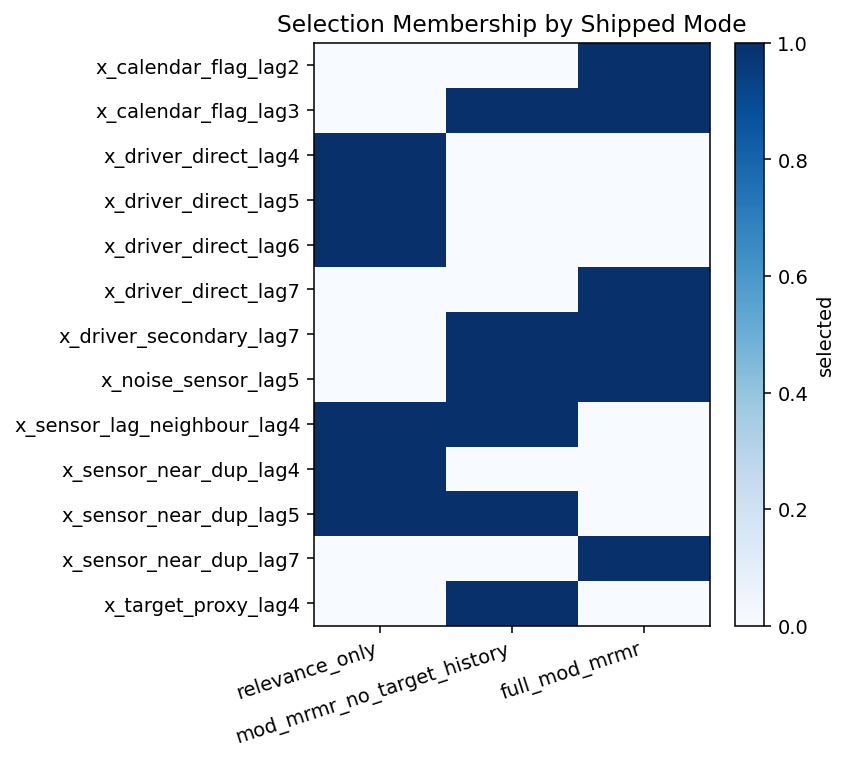

In [4]:
comparison_csv_path = TABLE_DIR / 'mode_selection_comparison.csv'
blocked_csv_path = TABLE_DIR / 'blocked_legality_rows.csv'
selected_csv_path = TABLE_DIR / 'full_selected_rows.csv'
figure_path = FIG_DIR / 'selection_modes_heatmap.png'

membership_df.to_csv(comparison_csv_path, index=False)
blocked_legality_df.to_csv(blocked_csv_path, index=False)
selected_full_df.to_csv(selected_csv_path, index=False)
_save_selection_heatmap(figure_path, membership_df)

print(f'Wrote comparison CSV: {_relative_output_path(comparison_csv_path)}')
print(f'Wrote blocked legality CSV: {_relative_output_path(blocked_csv_path)}')
print(f'Wrote selected rows CSV: {_relative_output_path(selected_csv_path)}')
print(f'Wrote figure: {_relative_output_path(figure_path)}')

display(Image(filename=str(figure_path)))

## Summary

- **Relevance-only** exposes the strongest individual candidates, but it does not suppress near-duplicate sensors, lag-neighbour duplicates, or target-history proxies.
- **ModMRMR without target-history novelty** adds forecast-safe sparse selection and suppresses duplicate covariate-lag candidates, but it can still keep a covariate that mainly mirrors the target's own legal history.
- **Full Lag-Aware ModMRMR** keeps the forecast-safe sparse selection step and then adds target-history novelty, which is the lever that should demote the `target_proxy` rows while leaving the legal known-future calendar rows explicitly labeled as such.

The blocked rows are part of the story: illegal measured lags never enter the scoring pool, so the sparse selection result remains forecast-horizon legal by construction.